In [20]:
import os
import re
import glob
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from pathlib import Path

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              precision_recall_fscore_support, accuracy_score)
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

**Step 1:** Set up and import of every neccessary python and deep learning libraries.

Imports libraries for data handling **(numpy, pandas)**, image I/O **(cv2)**, visualization **(matplotlib, seaborn)**, deep learning **(tensorflow/keras — CNN layers, ImageDataGenerator for augmentation, MobileNetV2 for transfer learning, and training callbacks)**, and evaluation **(sklearn metrics, class weighting)**. Sets a fixed random SEED (42),an arbitrary but conventional choice in ML code, chosen only for consistency.

In [21]:
def find_dataset_root(search_root="/kaggle/input"):
    for dirpath, dirnames, _ in os.walk(search_root):
        if "train" in dirnames:
            contents = os.listdir(os.path.join(dirpath, "train"))
            if "NORMAL" in contents and "PNEUMONIA" in contents:
                return dirpath
    return None

BASE_DIR = find_dataset_root()
assert BASE_DIR, "Dataset not found"

TRAIN_DIR, TEST_DIR = os.path.join(BASE_DIR, "train"), os.path.join(BASE_DIR, "test")
print("Root:", BASE_DIR, "| Train:", os.listdir(TRAIN_DIR), "| Test:", os.listdir(TEST_DIR))

IMG_SIZE, BATCH_SIZE, NUM_CLASSES = (224, 224), 32, 3
CLASS_NAMES = ["NORMAL", "BACTERIA", "VIRUS"]

Root: /kaggle/input/datasets/tolgadincer/labeled-chest-xray-images/chest_xray | Train: ['PNEUMONIA', 'NORMAL'] | Test: ['PNEUMONIA', 'NORMAL']


**Step 2:** Dataset Path Setup & Configuration

/kaggle/input/datasets/tolgadincer/labeled-chest-xray-images/chest_xray is the root folder.Inside it are two subfolders named train and test.And inside each train and test there are 2 class folder named "Norma" and "PNEUMONIA".There is no separate BACTERIA/VIRUS folder so both pneumonia types are combined into one PNEUMONIA folder.

IMG_SIZE, BATCH_SIZE, NUM_CLASSES = (224, 224), 32, 3
CLASS_NAMES = ["NORMAL", "BACTERIA", "VIRUS"]

This part sets project wide constants: target image size for resizing, batch size for training, number of output classes, and their names used consistently in later preprocessing and modeling cells.


In [22]:
def label_from_path(filepath):
    """Return one of NORMAL / BACTERIA / VIRUS based on folder + filename."""
    fname = os.path.basename(filepath).lower()
    parent = os.path.basename(os.path.dirname(filepath)).upper()
    if parent == "NORMAL":
        return "NORMAL"
    elif parent == "PNEUMONIA":
        if "bacteria" in fname:
            return "BACTERIA"
        elif "virus" in fname:
            return "VIRUS"
        else:
            return "UNKNOWN"
    return "UNKNOWN"

def build_dataframe(root_dir):
    filepaths = (glob.glob(os.path.join(root_dir, "*", "*.jpeg")) +
                 glob.glob(os.path.join(root_dir, "*", "*.jpg")) +
                 glob.glob(os.path.join(root_dir, "*", "*.png")))
    labels = [label_from_path(fp) for fp in filepaths]
    df = pd.DataFrame({"filepath": filepaths, "label": labels})
    df = df[df["label"] != "UNKNOWN"].reset_index(drop=True)
    return df

train_df_full = build_dataframe(TRAIN_DIR)
test_df = build_dataframe(TEST_DIR)

print("Train (full, pre-split) shape:", train_df_full.shape)
print("Test shape:", test_df.shape)

assert len(train_df_full) > 0, "train_df_full is empty — check BASE_DIR / dataset attachment above."
assert len(test_df) > 0, "test_df is empty — check BASE_DIR / dataset attachment above."
assert set(train_df_full["label"].unique()) == set(CLASS_NAMES), \
    f"Unexpected classes found: {train_df_full['label'].unique()}"

train_df_full.head()


Train (full, pre-split) shape: (5232, 2)
Test shape: (624, 2)


,filepath,label
0,/kaggle/input/datasets/tolgadincer/labeled-che...,VIRUS
1,/kaggle/input/datasets/tolgadincer/labeled-che...,BACTERIA
2,/kaggle/input/datasets/tolgadincer/labeled-che...,BACTERIA
3,/kaggle/input/datasets/tolgadincer/labeled-che...,BACTERIA
4,/kaggle/input/datasets/tolgadincer/labeled-che...,BACTERIA


**Step 3** : Build Labeled DataFrames

Parses each image's folder + filename to assign NORMAL/BACTERIA/VIRUS labels, builds train_df_full and test_df tables (filepath + label), and validates both are non-empty with all 3 classes present.

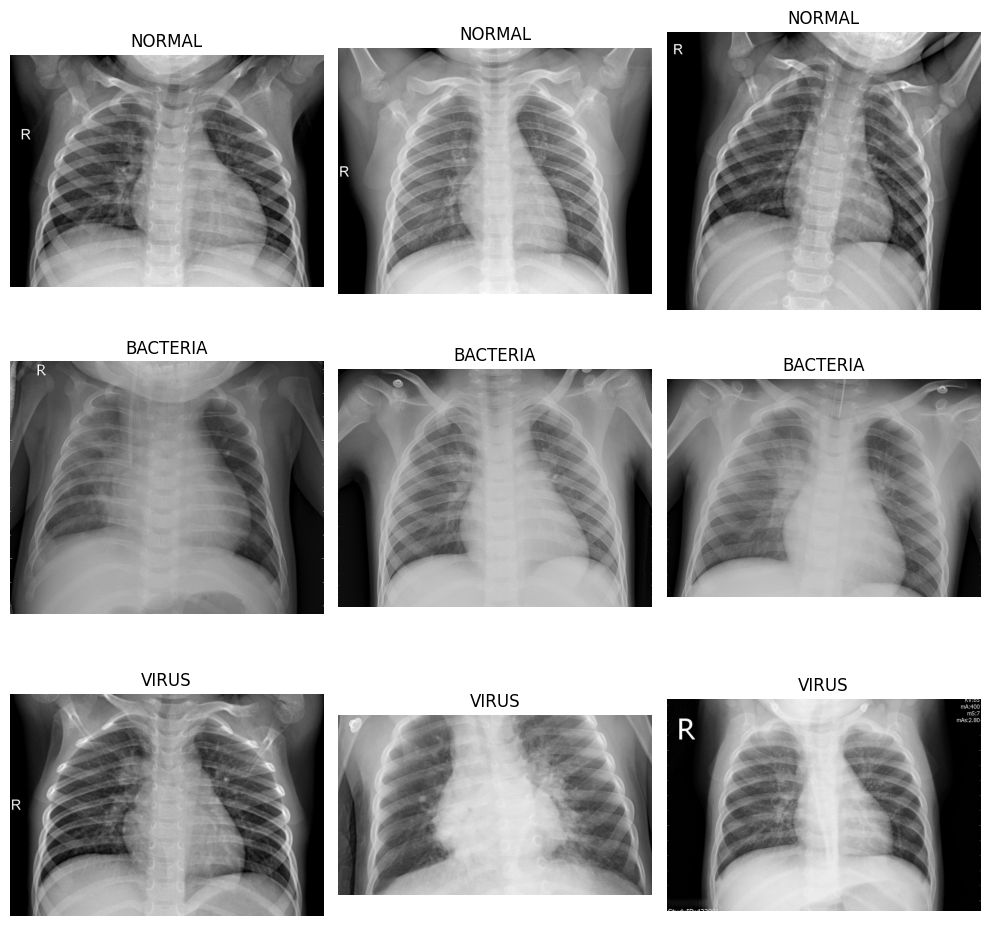

In [23]:
import matplotlib.pyplot as plt
from PIL import Image
import random

def get_samples_by_class(train_dir, n=3):
    """Returns a dict: class_name -> list of sample file paths"""
    samples = {"NORMAL": [], "BACTERIA": [], "VIRUS": []}
    
    normal_files = os.listdir(os.path.join(train_dir, "NORMAL"))
    samples["NORMAL"] = [
        os.path.join(train_dir, "NORMAL", f)
        for f in random.sample(normal_files, n)
    ]

    pneumonia_files = os.listdir(os.path.join(train_dir, "PNEUMONIA"))
    bacteria_files = [f for f in pneumonia_files if "bacteria" in f.lower()]
    virus_files = [f for f in pneumonia_files if "virus" in f.lower()]

    samples["BACTERIA"] = [
        os.path.join(train_dir, "PNEUMONIA", f)
        for f in random.sample(bacteria_files, n)
    ]
    samples["VIRUS"] = [
        os.path.join(train_dir, "PNEUMONIA", f)
        for f in random.sample(virus_files, n)
    ]
    return samples

samples = get_samples_by_class(TRAIN_DIR, n=3)

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for row, (class_name, paths) in enumerate(samples.items()):
    for col, path in enumerate(paths):
        img = Image.open(path).convert("L")  # grayscale
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].set_title(class_name)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

**Step 4:** Visualizing Sample Images

**get_samples_by_class()** picks 3 random images per class for a quick visual check.NORMAL images come straight from the NORMAL folder, while PNEUMONIA filenames are filtered by keyword ("bacteria" / "virus") to get BACTERIA and VIRUS samples separately.

The images are then displayed in a 3×3 grid  using matplotlib.

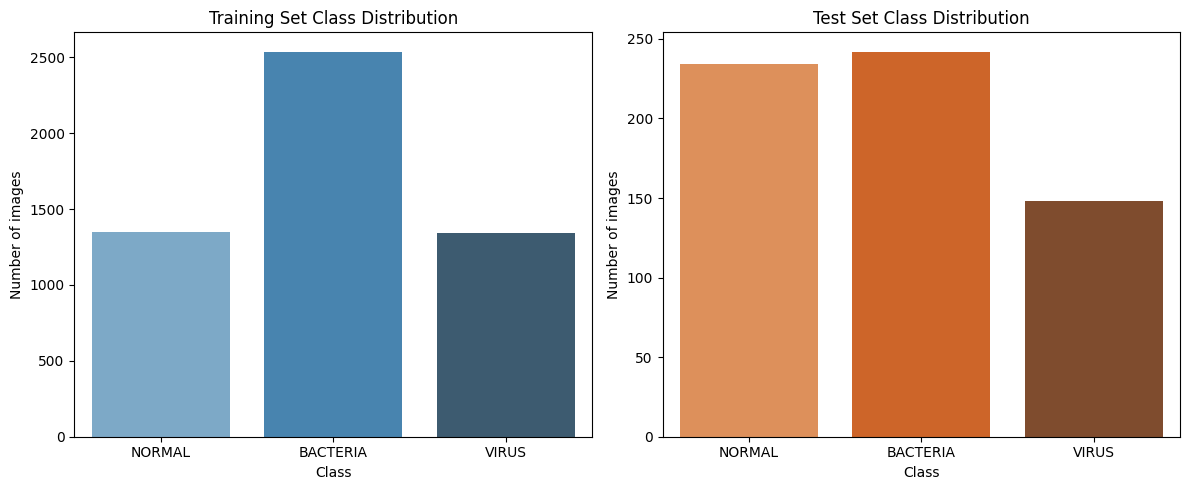

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

train_counts = train_df_full["label"].value_counts().reindex(CLASS_NAMES)
test_counts = test_df["label"].value_counts().reindex(CLASS_NAMES)

sns.barplot(x=train_counts.index, y=train_counts.values, hue=train_counts.index,
            palette="Blues_d", legend=False, ax=axes[0])
axes[0].set_title("Training Set Class Distribution")
axes[0].set_ylabel("Number of images")
axes[0].set_xlabel("Class")

sns.barplot(x=test_counts.index, y=test_counts.values, hue=test_counts.index,
            palette="Oranges_d", legend=False, ax=axes[1])
axes[1].set_title("Test Set Class Distribution")
axes[1].set_ylabel("Number of images")
axes[1].set_xlabel("Class")

plt.tight_layout()
plt.show()


**Step 5:** Class Distribution Visualization

This creates two side-by-side bar charts comparing how many images belong to each class (NORMAL, BACTERIA, VIRUS) in the training and test sets. **value_counts()** counts images per label, and **CLASS_NAMES** ensures the bars appear in a consistent order (NORMAL, BACTERIA, VIRUS) across both charts.This step reveals class imbalance .If one class has far more images than others, the model can become biased toward predicting the majority class.

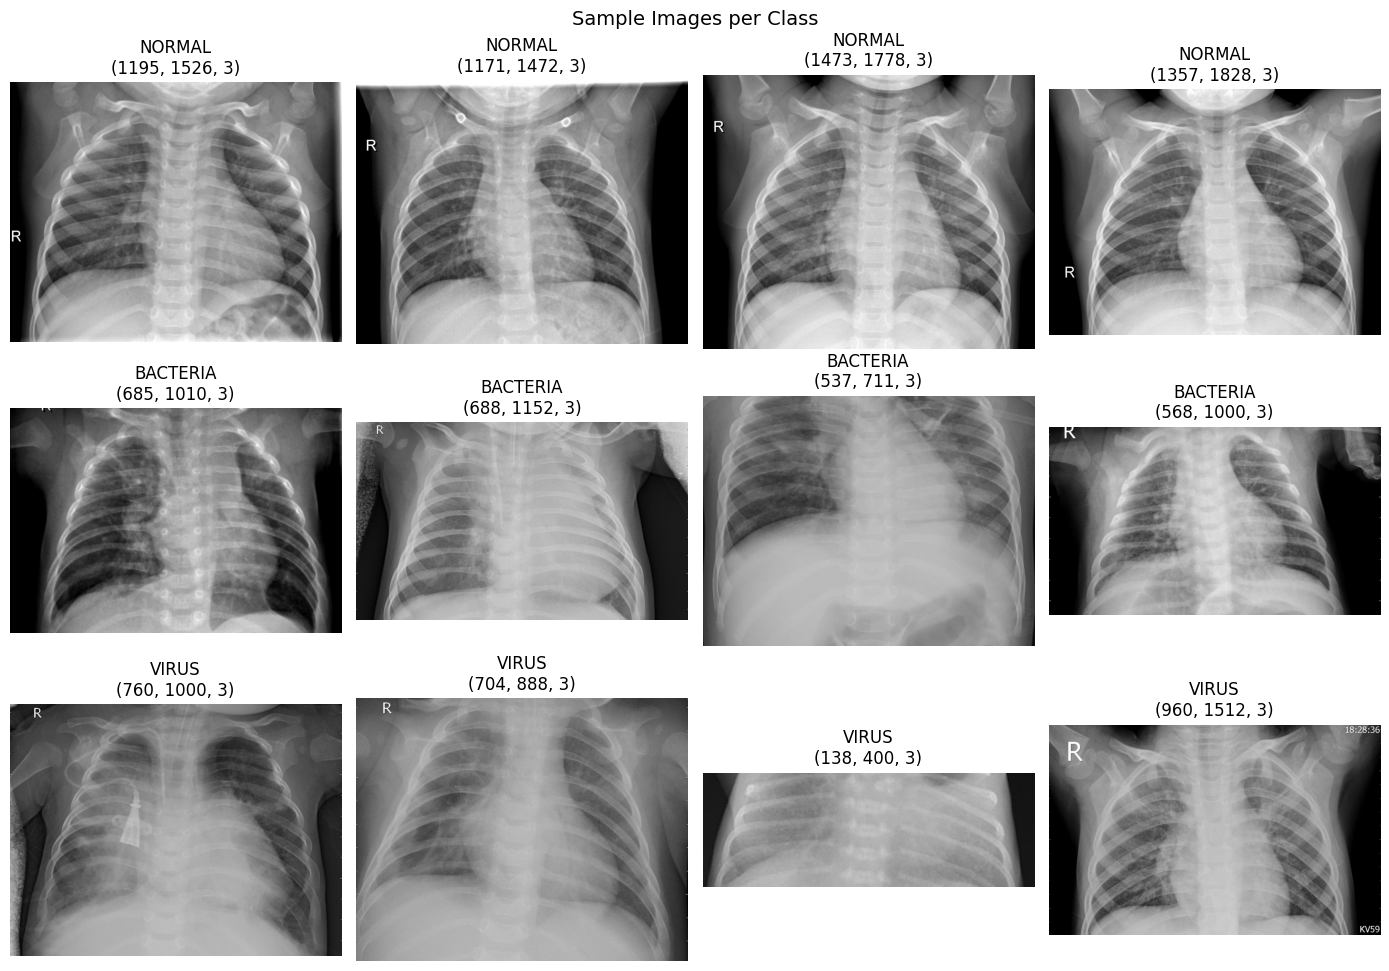

In [25]:
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
for row, cls in enumerate(CLASS_NAMES):
    sample_paths = train_df_full[train_df_full["label"] == cls]["filepath"].sample(4, random_state=SEED).tolist()
    for col, fp in enumerate(sample_paths):
        img = cv2.imread(fp)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[row, col].imshow(img)
        axes[row, col].set_title(f"{cls}\n{img.shape}")
        axes[row, col].axis("off")
plt.suptitle("Sample Images per Class", fontsize=14)
plt.tight_layout()
plt.show()


**Step 6 :** Sample Images per Class:

Randomly displays 3 grayscale images per class (NORMAL, BACTERIA, VIRUS), sourced directly from the raw folders rather than the DataFrame.So it's a visual check on the labeling logic.

In [26]:
sample_n = 200
sample_paths = train_df_full["filepath"].sample(min(sample_n, len(train_df_full)), random_state=SEED)
dims = []
formats = []
for fp in sample_paths:
    img = cv2.imread(fp)
    dims.append(img.shape[:2])
    formats.append(os.path.splitext(fp)[1].lower())

dims_df = pd.DataFrame(dims, columns=["height", "width"])
print("Image dimension stats (sample of", sample_n, "images):")
print(dims_df.describe())
print("\nFile formats found:", pd.Series(formats).value_counts().to_dict())


Image dimension stats (sample of 200 images):
            height        width
count   200.000000   200.000000
mean    987.960000  1325.280000
std     422.613356   381.187396
min     167.000000   428.000000
25%     688.000000  1060.000000
50%     896.000000  1264.000000
75%    1176.750000  1523.500000
max    2628.000000  2619.000000

File formats found: {'.jpeg': 200}


**Step 7:** Image Dimensions & Formats

This part checks if all the images are the same size and type before working with them.
It takes 200 random images from the training data, opens each one with OpenCV, and notes down its height and width as medical images often come in different sizes. It also checks the file extension (like .jpeg) for each image.

In [27]:
train_df, val_df = train_test_split(
    train_df_full,
    test_size=0.15,
    stratify=train_df_full["label"],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("Train:", train_df.shape, "| Val:", val_df.shape, "| Test:", test_df.shape)
print("\nTrain class balance:\n", train_df["label"].value_counts(normalize=True))
print("\nVal class balance:\n", val_df["label"].value_counts(normalize=True))


Train: (4447, 2) | Val: (785, 2) | Test: (624, 2)

Train class balance:
 label
BACTERIA    0.485046
NORMAL      0.257927
VIRUS       0.257027
Name: proportion, dtype: float64

Val class balance:
 label
BACTERIA    0.485350
VIRUS       0.257325
NORMAL      0.257325
Name: proportion, dtype: float64


**Step 8:** Train Validation Split 

This part splits the training data into two groups: one to actually train the model, and one to check its performance along the way, since the dataset came with train and test folders.It takes 85% of the training data for training and sets aside 15% as a validation set, keeping the class proportions the same in both groups . It also resets the row numbering for both groups.

In [28]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=15,
    horizontal_flip=True,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    fill_mode="nearest"
)

val_test_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    shuffle=True,
    seed=SEED
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    shuffle=False
)

print("Class indices mapping:", train_generator.class_indices)


Found 4447 validated image filenames belonging to 3 classes.
Found 785 validated image filenames belonging to 3 classes.
Found 624 validated image filenames belonging to 3 classes.
Class indices mapping: {'NORMAL': 0, 'BACTERIA': 1, 'VIRUS': 2}


**Step 9:** Data Generators & Augmentation

This part loads the images in batches and prepares them for the model.
For training images it rescales pixel values to 0–1 and applies random changes (rotation, flip, zoom, small shifts) to create more variety .That can help the model generalize better. For validation and test images, it only rescales without changes as those need to stay realistic for accurate evaluation.

**flow_from_dataframe** reads each image from its filepath, resizes it to 224×224, and groups them into batches of 32 with their correct labels.The output confirms 4,447 training, 785 validation, and 624 test images were loaded successfully. Three classes are numbered internally (NORMAL=0, BACTERIA=1, VIRUS=2) which is useful for reading the confusion matrix correctly.

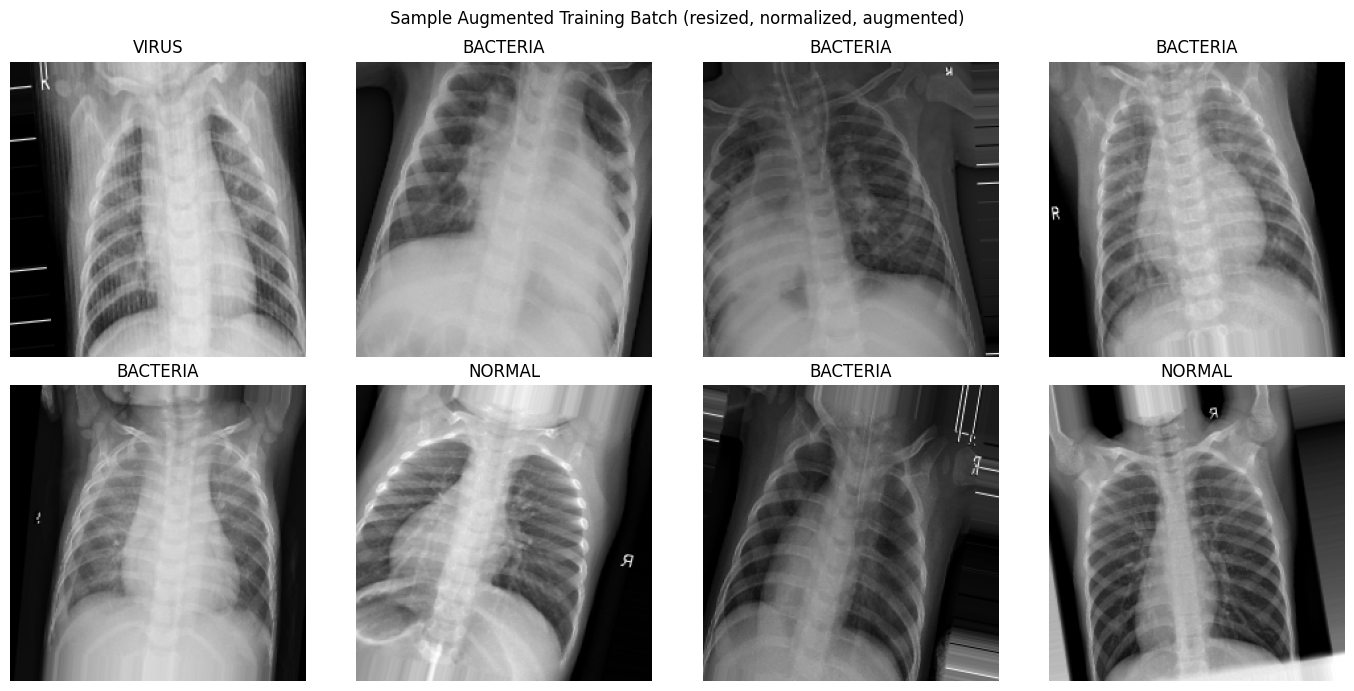

In [38]:
imgs, lbls = next(train_generator)
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(imgs[i])
    cls_idx = np.argmax(lbls[i])
    ax.set_title(CLASS_NAMES[cls_idx])
    ax.axis("off")
plt.suptitle("Sample Augmented Training Batch (resized, normalized, augmented)")
plt.tight_layout()
plt.show()


**Step 10:** Sanity Check — Visualize Augmented Batch

This part visually double checks that the generator from the previous step is actually working correctly before moving on to model building.
It pulls one batch of images and labels from train_generator, then plots 8 of them . For each image, it finds the class using np.argmax and uses that to show the correct class name as the title.
8 chest X-ray images that look slightly rotated, zoomed, flipped, or shifted compared to the originals .It confirms the augmentation is actually being applied not just rescaling. Each image's title (NORMAL/BACTERIA/VIRUS)  visually match mthe expectation that class. This step is a quick visual proof that your preprocessing pipeline (resize - normalize  - augment - label) is working correctly .

In [39]:
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.array(CLASS_NAMES),
    y=train_df["label"].values
)
class_weights = {i: w for i, w in enumerate(class_weights_array)}
print("Computed class weights:", dict(zip(CLASS_NAMES, class_weights_array)))


Computed class weights: {'NORMAL': np.float64(1.2923568730020343), 'BACTERIA': np.float64(0.6872199041879153), 'VIRUS': np.float64(1.2968795567220763)}


**Step 11:** Class Weights for Imbalance

Since BACTERIA has almost twice as many images as NORMAL or VIRUS, this part calculates class weights so the model doesn't get biased toward the majority class.The output shows BACTERIA gets a lower weight (0.69) since it's overrepresented while NORMAL (1.29) and VIRUS (1.30) get higher weights as they are underrepresented

In [40]:
def build_cnn(input_shape=(224, 224, 3), num_classes=3):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),

        layers.GlobalAveragePooling2D(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax")
    ])
    return model

cnn_model = build_cnn()
cnn_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
cnn_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,035 (1.05 MB)

 Trainable params: 275,331 (1.05 MB)

 Non-trainable params: 704 (2.75 KB)

**Step 12:** Build & Compile the CNN Model Implementation

This part builds the actual CNN model from scratch.The summary table lists every layer.Its output shape, and how many parameters  it has. The image shrinks from 224×224 - 112 - 56 - 28 - 14 as it passes through the 4 pooling layers, while the channel depth grows (32-64-128-128), which is the CNN "learning more, seeing less" pattern. Total params: 276,035  a fairly small, lightweight model (1.05 MB), which is reasonable for a basic CNN and trains quickly. Almost all params are trainable (275,331), with only 704 non-trainable ones coming from **BatchNormalization**'s internal stats.

In [43]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
    ModelCheckpoint("best_basic_cnn.keras", monitor="val_accuracy", save_best_only=True)
]

EPOCHS = 15

history_cnn = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)


Epoch 1/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 114s 822ms/step - accuracy: 0.6654 - loss: 0.7013 - val_accuracy: 0.2586 - val_loss: 1.6911 - learning_rate: 1.0000e-04
Epoch 2/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 93s 671ms/step - accuracy: 0.6933 - loss: 0.6603 - val_accuracy: 0.4076 - val_loss: 2.0018 - learning_rate: 1.0000e-04
Epoch 3/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 94s 673ms/step - accuracy: 0.7097 - loss: 0.6257 - val_accuracy: 0.4178 - val_loss: 1.9291 - learning_rate: 1.0000e-04
Epoch 4/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 93s 672ms/step - accuracy: 0.7243 - loss: 0.6060 - val_accuracy: 0.5580 - val_loss: 0.9828 - learning_rate: 1.0000e-04
Epoch 5/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 94s 673ms/step - accuracy: 0.7342 - loss: 0.5879 - val_accuracy: 0.6904 - val_loss: 0.6648 - learning_rate: 1.0000e-04
Epoch 6/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 91s 656ms/step - accuracy: 0.7311 - loss: 0.5710 - val_accuracy: 0.7210 - val_loss: 0.6226 - learning_rate: 1.0000e-04
Epoch 7/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 91s 6

**Step 13:** Model Training

This part trains the CNN on the training data for 15 epochs means full passes through the dataset, using the validation set to check performance after each epoch.

Three callbacks control the training: **EarlyStopping** stops training if validation loss stops improving for 5 epochs and keeps the best weights,**ReduceLROnPlateau** lowers the learning rate if validation loss stalls for 3 epochs, and **ModelCheckpoint** saves the best-performing model to a file. class_weight=class_weights is passed in so the model gives more importance to the underrepresented classes (NORMAL, VIRUS) as calculated in step 11.

In [44]:
def build_transfer_model(input_shape=(224, 224, 3), num_classes=3, fine_tune_at=100):
    base_model = MobileNetV2(input_shape=input_shape, include_top=False, weights="imagenet")
    base_model.trainable = True
    for layer in base_model.layers[:fine_tune_at]:
        layer.trainable = False

    inputs = layers.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs)
    return model

tl_model = build_transfer_model()
tl_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
tl_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,586,691 (9.87 MB)

 Trainable params: 2,190,147 (8.35 MB)

 Non-trainable params: 396,544 (1.51 MB)

**Step 14:** Transfer Learning Model 

This part builds a second model using MobileNetV2.

**include_top=False** removes MobileNetV2's original classification layer, keeping only its feature-extracting layers. The loop then freezes the earlier layers (fine_tune_at=100) so their general learned features stay unchanged. 
**GlobalAveragePooling2D** - Dense(256)- Dropout(0.5)- Dense(3, softmax) for the final classification into NORMAL, BACTERIA, or VIRUS.

In [31]:
train_generator.reset()
val_generator.reset()

tl_callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
    ModelCheckpoint("best_transfer_model.keras", monitor="val_accuracy", save_best_only=True)
]

history_tl = tl_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=tl_callbacks
)


Epoch 1/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 0s 562ms/step - accuracy: 0.7522 - loss: 0.5270

2026-09-23 19:57:12.458927: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-23 19:57:12.595432: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


139/139 ━━━━━━━━━━━━━━━━━━━━ 101s 726ms/step - accuracy: 0.7655 - loss: 0.5095 - val_accuracy: 0.5274 - val_loss: 2.7844 - learning_rate: 1.0000e-04
Epoch 2/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 85s 609ms/step - accuracy: 0.7909 - loss: 0.4605 - val_accuracy: 0.5006 - val_loss: 2.9334 - learning_rate: 1.0000e-04
Epoch 3/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 84s 603ms/step - accuracy: 0.8030 - loss: 0.4187 - val_accuracy: 0.5325 - val_loss: 2.7213 - learning_rate: 1.0000e-04
Epoch 4/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 85s 609ms/step - accuracy: 0.8127 - loss: 0.4074 - val_accuracy: 0.5987 - val_loss: 1.4435 - learning_rate: 1.0000e-04
Epoch 5/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 85s 610ms/step - accuracy: 0.8239 - loss: 0.3849 - val_accuracy: 0.5732 - val_loss: 1.4784 - learning_rate: 1.0000e-04
Epoch 6/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 87s 628ms/step - accuracy: 0.8291 - loss: 0.3606 - val_accuracy: 0.5643 - val_loss: 1.7543 - learning_rate: 1.0000e-04
Epoch 7/15
139/139 ━━━━━━━━━━━━━━━━━━━━ 87s 624ms/step -

**Step 15:** Train the Transfer Learning Model

**train_generator.reset()** and **val_generator.reset()** rewind both generators back to the start.So this training run begins from the first batch .

This trains **tl_model** (**the MobileNetV2 transfer learning model**) for the same number of epochs as the basic CNN, using the same class weights to handle class imbalance, and the same three callbacks. 

In [52]:
FINAL_MODEL = tl_model
FINAL_HISTORY = history_tl
FINAL_MODEL_NAME = "Transfer Learning (MobileNetV2)"

print(f"Using: {FINAL_MODEL_NAME}")
print(FINAL_MODEL.summary())

NameError: name 'history_tl' is not defined

**Step 16:** Select the Final Model

It assigns tl_model to FINAL_MODEL, history_tl (the epoch-by-epoch) to FINAL_HISTORY, and a readable name to FINAL_MODEL_NAME for labeling charts and outputs.

In [53]:
test_generator.reset()
y_pred_probs = FINAL_MODEL.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes  # true labels in same order as predictions (shuffle=False)

print("Test accuracy:", accuracy_score(y_true, y_pred))

2026-09-24 19:44:29.709888: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-24 19:44:29.847664: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


19/20 ━━━━━━━━━━━━━━━━━━━━ 0s 524ms/step

2026-09-24 19:44:51.127215: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-09-24 19:44:51.264760: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


20/20 ━━━━━━━━━━━━━━━━━━━━ 34s 1s/step 
Test accuracy: 0.375


**Step 17:** Predict on Test Set & Compute Accuracy

Runs the final model on all 624 test images, gets its predicted labels, and compares them to the true labels to get overall test accuracy.


In [72]:
report = classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4)
print(report)

precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, average="macro")
print(f"\nMacro Precision: {precision:.4f} | Macro Recall: {recall:.4f} | Macro F1: {f1:.4f}")

              precision    recall  f1-score   support

      NORMAL     1.0000    0.6197    0.7652       234
    BACTERIA     0.7649    0.9545    0.8493       242
       VIRUS     0.6158    0.7365    0.6708       148

    accuracy                         0.7772       624
   macro avg     0.7936    0.7702    0.7617       624
weighted avg     0.8177    0.7772    0.7754       624


Macro Precision: 0.7936 | Macro Recall: 0.7702 | Macro F1: 0.7617


**Step 18:** Detailed Classification Report

Shows precision, recall, and F1-score for each class separately not just one overall accuracy number.

Overall test accuracy is 77.7% . NORMAL is very precise but misses some real cases (recall 0.62). BACTERIA performs best overall. VIRUS is the weakest class (F1 0.67).

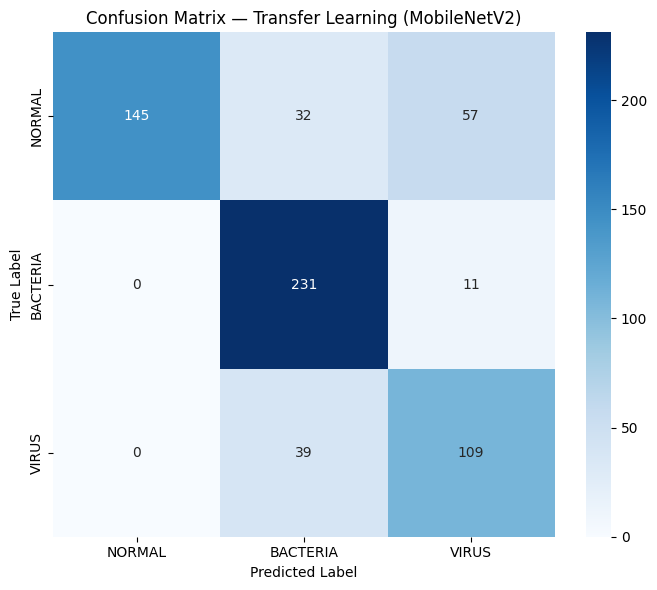

In [73]:
cm = confusion_matrix(y_true, y_pred)
cm_df = pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES)

plt.figure(figsize=(7, 6))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=True)
plt.title(f"Confusion Matrix — {FINAL_MODEL_NAME}")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()


**Step 19:** Confusion Matrix

This shows a table of what the model got right and what it mixed up. Each row is the real answer, each column is what the model guessed. The diagonal (top-left to bottom-right) shows correct guesses .

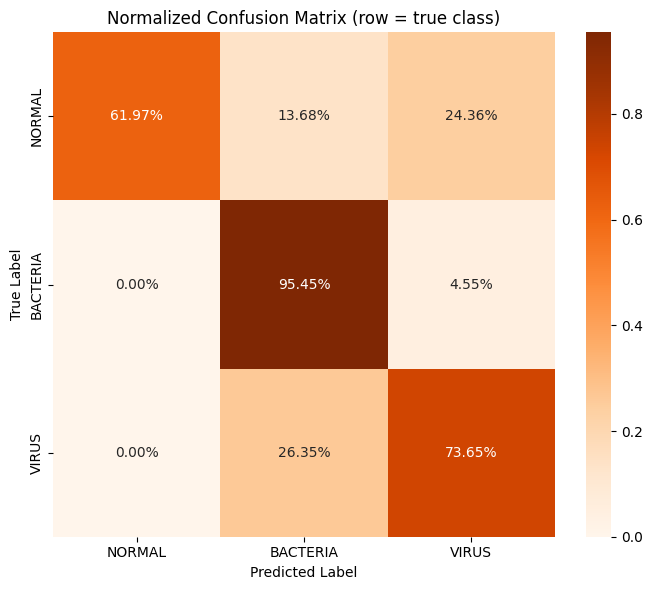

Bacteria<->Virus mutual confusion rate (fraction of those classes' samples): 30.90%


In [74]:
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
cm_norm_df = pd.DataFrame(cm_norm, index=CLASS_NAMES, columns=CLASS_NAMES)

plt.figure(figsize=(7, 6))
sns.heatmap(cm_norm_df, annot=True, fmt=".2%", cmap="Oranges")
plt.title("Normalized Confusion Matrix (row = true class)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

bact_idx, virus_idx = CLASS_NAMES.index("BACTERIA"), CLASS_NAMES.index("VIRUS")
bv_confusion_rate = cm_norm[bact_idx, virus_idx] + cm_norm[virus_idx, bact_idx]
print(f"Bacteria<->Virus mutual confusion rate (fraction of those classes' samples): {bv_confusion_rate:.2%}")


**Step 20:** Normalized Confusion Matrix & Bacteria-vs-Virus Confusion Rate

Converts the confusion matrix into percentages per row, so it shows what % of each true class got predicted correctly or wrongly .

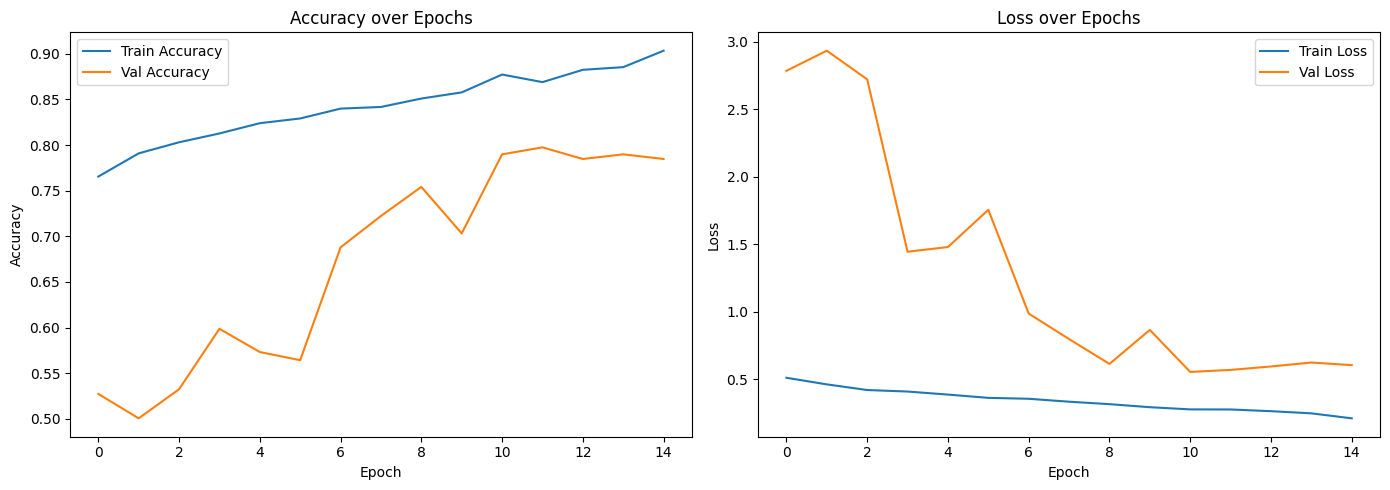

In [75]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(FINAL_HISTORY.history["accuracy"], label="Train Accuracy")
axes[0].plot(FINAL_HISTORY.history["val_accuracy"], label="Val Accuracy")
axes[0].set_title("Accuracy over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(FINAL_HISTORY.history["loss"], label="Train Loss")
axes[1].plot(FINAL_HISTORY.history["val_loss"], label="Val Loss")
axes[1].set_title("Loss over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()


**Step 21:** Training vs Validation Curves

Plots two side-by-side charts using the saved training history: accuracy over epochs on the left, loss over epochs on the right, each showing training vs. validation lines together for comparison. These curves show whether the model is learning well, overfitting or underfitting.

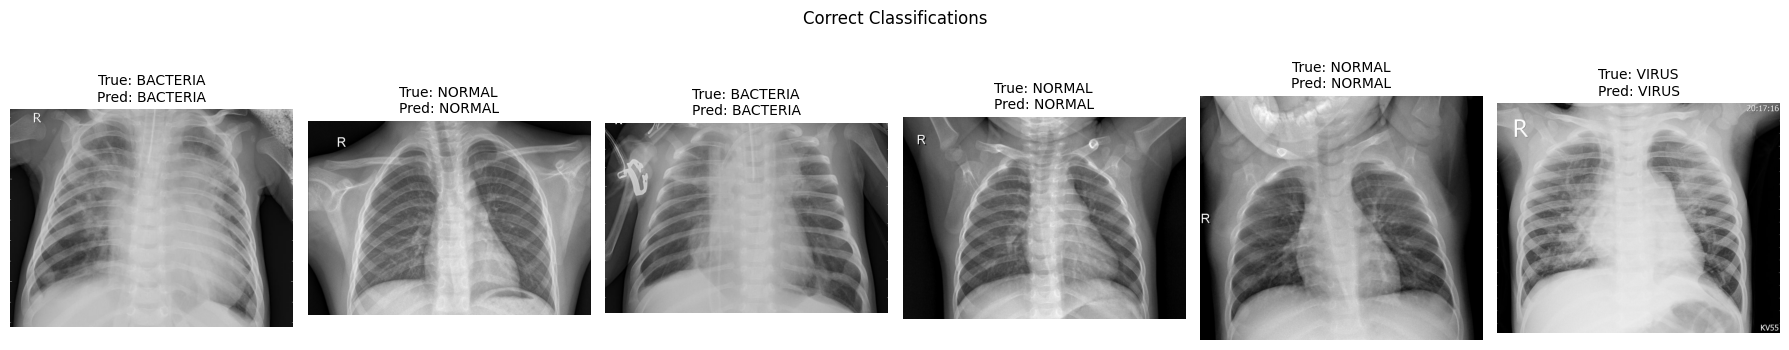

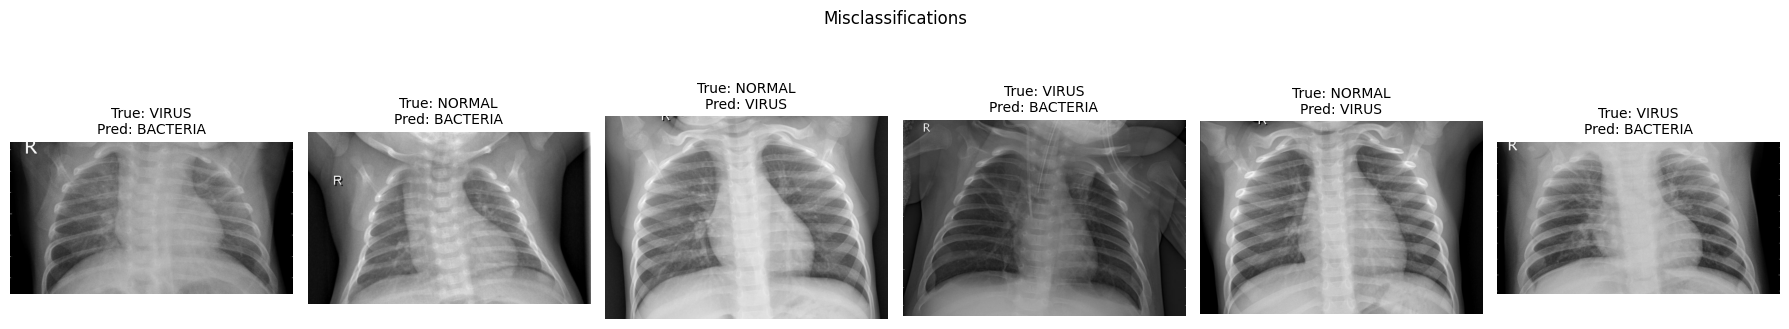

In [76]:
filepaths = test_generator.filepaths

correct_idx = np.where(y_pred == y_true)[0]
wrong_idx = np.where(y_pred != y_true)[0]

def plot_samples(indices, title, n=6):
    n = min(n, len(indices))
    if n == 0:
        print(f"No samples to show for: {title}")
        return
    chosen = np.random.choice(indices, n, replace=False)
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 4))
    if n == 1:
        axes = [axes]
    for ax, idx in zip(axes, chosen):
        img = cv2.imread(filepaths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(f"True: {CLASS_NAMES[y_true[idx]]}\nPred: {CLASS_NAMES[y_pred[idx]]}", fontsize=10)
        ax.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_samples(correct_idx, "Correct Classifications", n=6)
plot_samples(wrong_idx, "Misclassifications", n=6)


**Step 22:** Sample Correct & Incorrect Predictions

This visually shows actual test images alongside what the model predicted vs. what was actually true.

**Filepaths** gets the file path of every test image. **correct_idx** and **wrong_idx** find which predictions matched or didn't match the true labels. **plot_samples()** is a reusable function that randomly picks  images from a given set of indices and loads each with OpenCV

**Expected Insights & Discussion**

**Bacterial vs. viral pneumonia detection**
The NORMAL class was the one most easily identified correctly  with a precision of 1.00 but the model failed to identify some of the actual NORMAL cases as its recall was 0.62.Probably because it mistook them for pneumonia. VIRUS was the most difficult class as a whole with an F1 score of 0.67 since both its precision and recall were lower than those for BACTERIA and NORMAL. 

**2. Impact of data imbalance**

Data imbalance happens when some classes in a dataset have a lot more samples than other classes. This can cause problems in model training. The model might be biased towards majority class. As a result accuracy becomes high in traing phase  but the model fails to spot important patterns in the test data. 
BACTERIA had nearly twice as many training images Than the NORMAL or the VIRUS categories .Here nearly 48.5% of BACTERIA image compared to 25.8% for NORMAL and 25.7% for VIRUS. For this class weights were applied to impose a heavier penalty for misclassifying NORMAL or VIRUS cases. BACTERIA still achieved the highest recall (0.95) that said the model still shows a slight preference for the majority class .

**3. The effectiveness of augmentation and preprocessing**

The model kept getting better and better on the training data. But on the validation data  images it hadn't specifically trained on .its accuracy jumped up and down unpredictably instead of steadily improving. This shows the augmentation (rotating, flipping, zooming the images) did help the model a little, but its performance was still shaky.
**4. Limits of models in medical diagnosis**
This model is not suitable for use in actual clinical diagnosis .Only  been trained on a small pediatric dataset taken from a single sourc. The purpose of this project is to learn the application of AI to healthcare imaging.





**AI Usage Declaration**:

LLMs were used to help identify and debug errors, and to get explanations for new concepts arrived during this project. All suggestions were reviewed and verified before being included in the final project.The code, analysis, and markdown documentation were written based on my own understanding.